In [3]:
import pandas as pd
import numpy as np 
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
State_tnx_users = pd.read_excel('phonepay.xlsx',sheet_name='State_tax_users')
State_tnx = pd.read_excel('phonepay.xlsx',sheet_name='State_tax_split')
State_device = pd.read_excel('phonepay.xlsx',sheet_name='State_device')
District = pd.read_excel('phonepay.xlsx',sheet_name='District_tnx and users')
District_demographics = pd.read_excel('phonepay.xlsx',sheet_name='District Demographics')

In [624]:
State_tnx_users.describe()
State_tnx_users.info()
State_tnx.describe()
State_tnx_users.info()
State_device.describe()
State_device.info()
District.describe()
District.info()
District_demographics.describe()
District_demographics.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      504 non-null    int64  
 4   Amount (INR)      504 non-null    float64
 5   ATV (INR)         504 non-null    float64
 6   Registered Users  504 non-null    int64  
 7   App Opens         504 non-null    int64  
dtypes: float64(2), int64(5), object(1)
memory usage: 31.6+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 504 entries, 0 to 503
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   State             504 non-null    object 
 1   Year              504 non-null    int64  
 2   Quarter           504 non-null    int64  
 3   Transactions      5

In [465]:
state_missing_values = State_tnx_users.isnull().sum()
state_tnx_missing_values = State_tnx.isnull().sum()
state_missing_values = (state_missing_values/len(State_tnx_users))*100
state_tnx_missing_values = (state_tnx_missing_values/len(State_tnx))*100
State_device_missing_values = State_device.isnull().sum()
State_device_missing_values = (State_device_missing_values/len(State_device))*100
District_missing_values = District.isnull().sum()
District_missing_values = (District_missing_values/len(District))*100
District_demographics_missing_values = District_demographics.isnull().sum()
District_demographics_missing_values = (District_demographics_missing_values/len(District_demographics))*100

In [466]:
state_missing_values,state_tnx_missing_values,State_device_missing_values,District_missing_values,District_demographics_missing_values

(State               0.000000
 Year                0.000000
 Quarter             0.000000
 Transactions        0.000000
 Amount (INR)        0.198413
 ATV (INR)           0.000000
 Registered Users    0.000000
 App Opens           0.000000
 dtype: float64,
 State               0.0
 Year                0.0
 Quarter             0.0
 Transaction Type    0.0
 Transactions        0.0
 Amount (INR)        0.0
 ATV (INR)           0.0
 dtype: float64,
 State               0.0
 Year                0.0
 Quarter             0.0
 Brand               0.0
 Registered Users    0.0
 Percentage          0.0
 dtype: float64,
 State               0.000000
 Year                0.000000
 Quarter             0.000000
 District            0.000000
 Code                0.273224
 Transactions        0.000000
 Amount (INR)        0.000000
 ATV (INR)           0.039032
 Registered Users    0.000000
 App Opens           0.000000
 dtype: float64,
 State             0.0
 District          0.0
 Headquarters      0.

In [ ]:
Q1 How people across india use phonepay?
Q2 How tnx vary by state/district/year/quarter?
Q3 How demographics influence tnx?
Q4 How device type or tnx type impact the usage?
Q5 If entire data is consistent & relaible?

which states are most active over all 
what tnx dominated in each state or quarter 
state device shows which brand mobile use
which distrit drives state performance 
transaction trend over time 

In [376]:
# Q1 Total_states Total District and State with most District 
print(f'Number of States = {State_tnx_users['State'].nunique()}\nTotal number of District = {District.groupby('State')['District'].nunique().sum()}')
District.groupby('State')['District'].nunique().sort_values(ascending=False).head(1).reset_index()

Number of States = 36
Total number of District = 732


,State,District
0,Uttar Pradesh,75


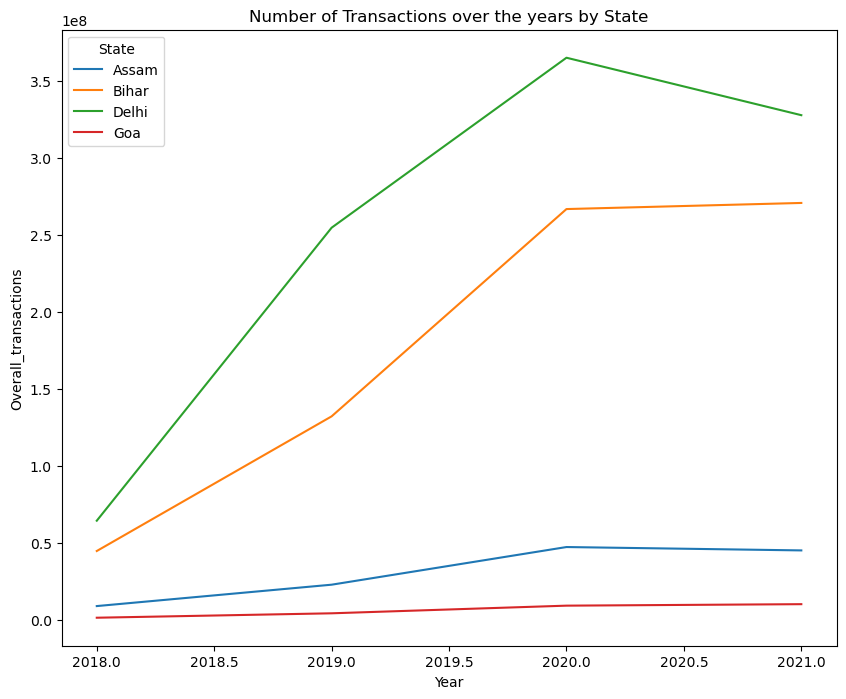

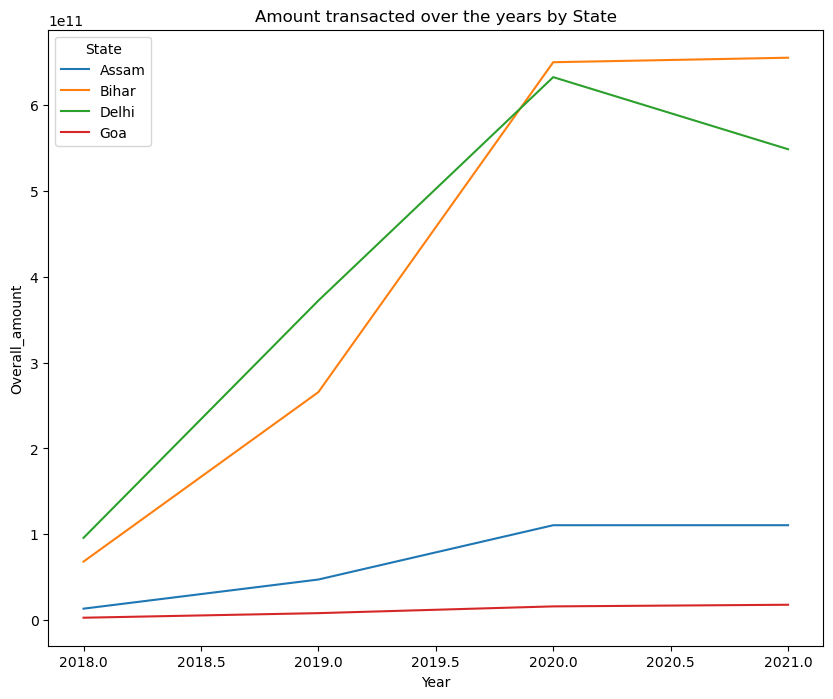

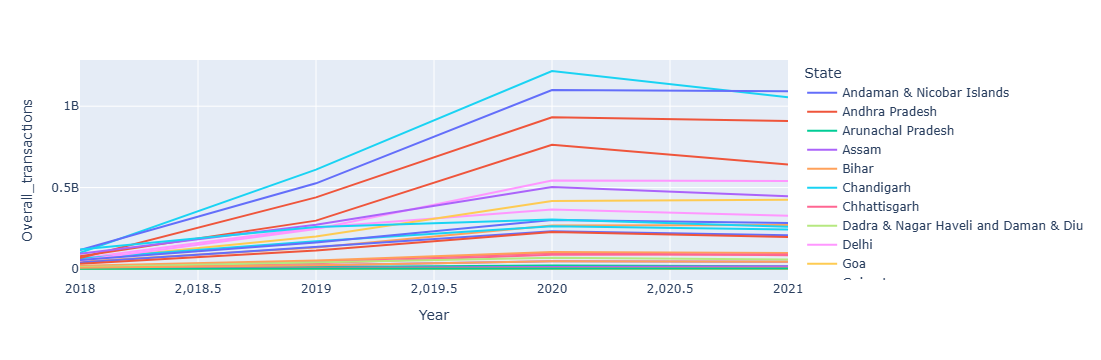

<Figure size 1000x800 with 0 Axes>

In [374]:
# Q2 Total Transactions and total transaction amount for each state over years 
Total_transactions = State_tnx.groupby(['Year','State']).agg(Overall_transactions=('Transactions','sum')).reset_index()
states = ['Assam','Bihar','Goa','Delhi']
plt.figure(figsize=(10,8))
sns.lineplot(data=Total_transactions[Total_transactions['State'].isin(states)],
            x='Year', y='Overall_transactions', hue='State')
plt.title('Number of Transactions over the years by State')
plt.show()

Total_amount = State_tnx.groupby(['Year','State']).agg(Overall_amount=('Amount (INR)','sum')).reset_index()
plt.figure(figsize=(10,8))
sns.lineplot(data=Total_amount[Total_amount['State'].isin(states)],
            x='Year', y='Overall_amount', hue='State')

plt.title('Amount transacted over the years by State')
plt.show()

import plotly.express as px
plt.figure(figsize=(10,8))
px.line(Total_transactions,
        x='Year',
        y='Overall_transactions',
        color='State')


In [372]:
# Q2.2 = Top 5 states with highest and lowest transaction volume
state_sum = State_tnx_users.groupby('State')['Transactions'].sum().reset_index()

top_5_states = state_sum.sort_values(by='Transactions', ascending=False).head(5)
bottom_5_states = state_sum.sort_values(by='Transactions', ascending=True).head(5)

print("Top 5 Highest Transaction Volume States:")
print(top_5_states)

print("\nTop 5 Lowest Transaction Volume States:")
print(bottom_5_states)

Top 5 Highest Transaction Volume States:
             State  Transactions
15       Karnataka    2981044533
20     Maharashtra    2833670154
31       Telangana    2347430243
1   Andhra Pradesh    1781091169
28       Rajasthan    1382918930

Top 5 Lowest Transaction Volume States:
                        State  Transactions
18                Lakshadweep         71610
0   Andaman & Nicobar Islands       1223565
17                     Ladakh       1880109
23                    Mizoram       2162776
22                  Meghalaya       5648913


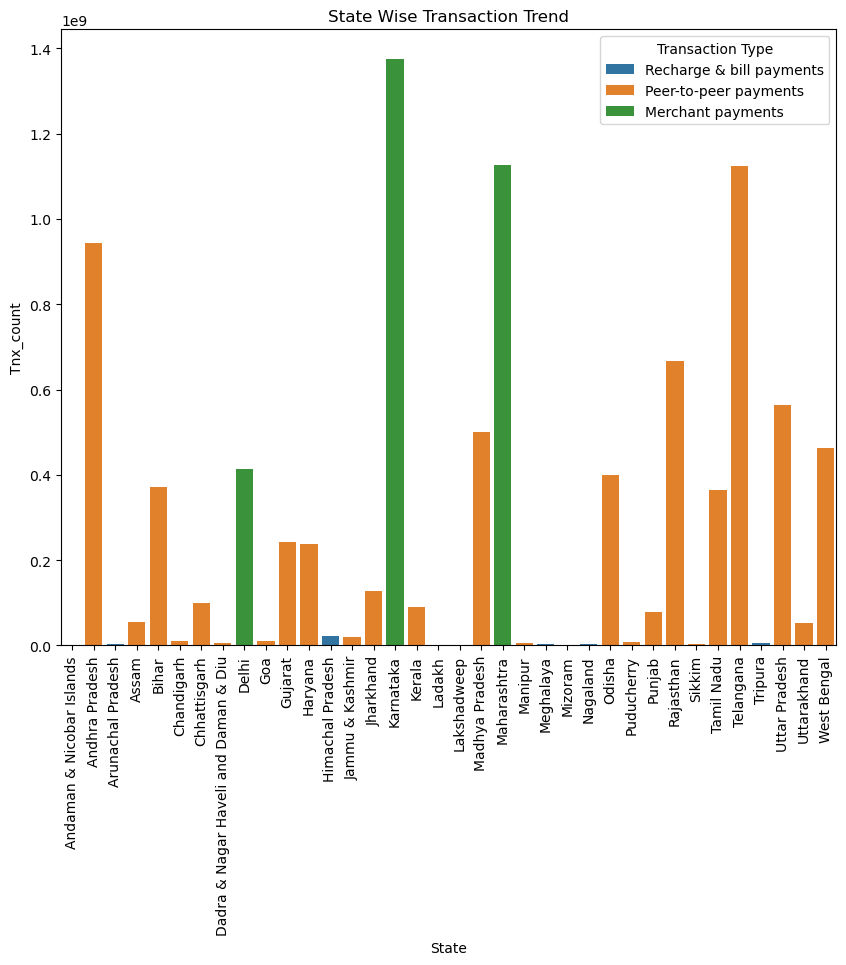

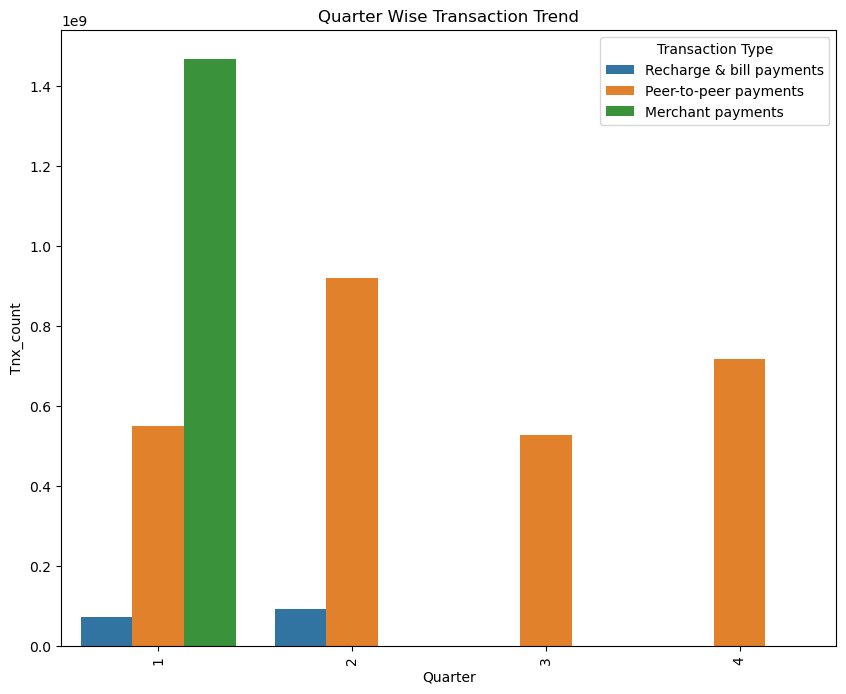

In [392]:
# Q3 Identifying most common transaction type over state and quarter 
Quarter_wise = State_tnx.groupby(['Year','Quarter','Transaction Type']).agg(Tnx_count = ('Transactions',
                                                                                  'sum')).reset_index()
Quarter_wise = Quarter_wise.loc[Quarter_wise.groupby(['Year','Quarter'])['Tnx_count'].idxmax()]

State_wise = State_tnx.groupby(['State','Transaction Type']).agg(Tnx_count = ('Transactions','sum')).reset_index()
State_wise = State_wise.loc[State_wise.groupby('State')['Tnx_count'].idxmax()]

plt.figure(figsize=(10,8))
sns.barplot(data=State_wise,x='State',y='Tnx_count',hue='Transaction Type')
plt.xticks(rotation=90)
plt.title('State Wise Transaction Trend')
plt.show()

years = [2018]
for year in years:
    temp= Quarter_wise[Quarter_wise['Year'].isin(Years)]
    plt.figure(figsize=(10,8))
    sns.barplot(data=Quarter_wise,x='Quarter',y='Tnx_count',hue='Transaction Type',errorbar=None)

plt.xticks(rotation=90)
plt.title('Quarter Wise Transaction Trend')
plt.show()


In [380]:
# Q4 Identify Device brand used by the highest registered users in eacgh state 

Devices_users = State_device.groupby(['State','Brand']).agg(Total_users=('Registered Users','sum')).reset_index()
Devices_users = Devices_users.loc[Devices_users.groupby(['State'])['Total_users'].idxmax()]
#Devices_users[Devices_users['State']=='Lakshadweep'].sort_values(by='Total_users',ascending=False)
Devices_users

,State,Brand,Total_users
11,Andaman & Nicobar Islands,Xiaomi,97889
22,Andhra Pradesh,Xiaomi,40061549
34,Arunachal Pradesh,Xiaomi,437803
46,Assam,Xiaomi,6979357
60,Bihar,Xiaomi,33721314
73,Chandigarh,Xiaomi,896628
85,Chhattisgarh,Xiaomi,8763373
98,Dadra & Nagar Haveli and Daman & Diu,Xiaomi,638834
109,Delhi,Xiaomi,24114984
120,Goa,Xiaomi,1208672


In [382]:
# Q5 Identifying districts with highest population for each state 
District_pop = District_demographics.groupby(['State','District']).agg(Total_population=('Population','sum')).reset_index()

District_pop = District_pop.loc[District_pop.groupby('State')['Total_population'].idxmax()]
District_pop.sort_values(by='Total_population',ascending=False).head(5)

,State,District,Total_population
734,West Bengal,North 24 Parganas,10082852.0
272,Karnataka,Bangalore Urban,9588910.0
397,Maharashtra,Pune,9426959.0
158,Gujarat,Ahmedabad,7208200.0
554,Tamil Nadu,Chennai,7139882.0


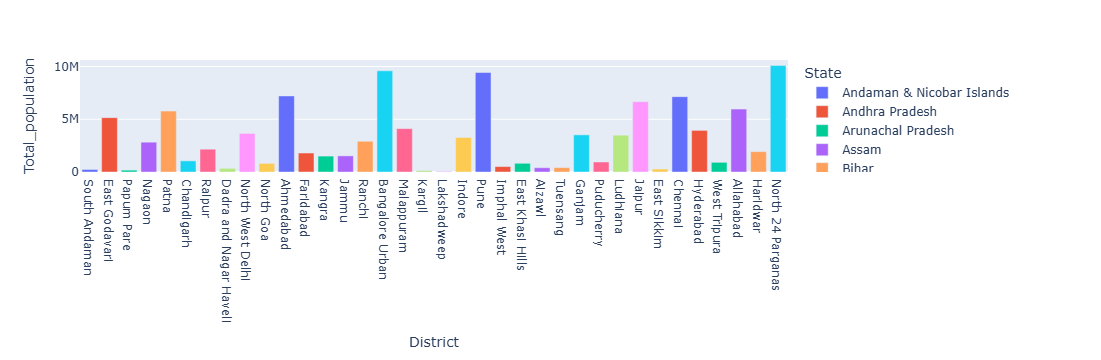

In [390]:
# Q5,2 = Creating chart for above data 
px.bar(District_pop,
        x='District',
        y='Total_population',
        color='State')


In [384]:
# Q6 Average Transaction Value per State (ATV)

ATV = State_tnx_users.groupby('State').agg(Total_amount=('Amount (INR)','sum'),
                                    Total_transaction = ('Transactions','sum')).reset_index()
ATV['ATV'] = ATV['Total_amount']/ATV['Total_transaction']

print('Top 5 States with highest ATV')
ATV.sort_values(by='ATV',ascending=False).head(5)

Top 5 States with highest ATV


,State,Total_amount,Total_transaction,ATV
17,Ladakh,6.606978e+09,1880109,3514.146494
0,Andaman & Nicobar Islands,3.641818e+09,1223565,2976.399178
23,Mizoram,6.317141e+09,2162776,2920.848685
21,Manipur,3.579325e+10,12318043,2905.757931
24,Nagaland,1.638757e+10,5864977,2794.140997


In [ ]:
print('Top 5 States with lowest ATV')
ATV.sort_values(by='ATV',ascending=True).head(5)

In [344]:
#Q7 App usage over the years and quarters 

mask = ((State_tnx_users['State']=='West Bengal') & (State_tnx_users['App Opens']==0))
#State_tnx_users = State_tnx_users.drop(columns='Transaction Category')
State_tnx_users.loc[mask,'App Opens'] = round(State_tnx_users['App Opens']
                                              [(State_tnx_users['State']=='West Bengal')
                                              & (State_tnx_users['App Opens']>0)].mean())

State_tnx_users['App Opens'] = (
    State_tnx_users.groupby('State')['App Opens']
    .transform(lambda x: x.mask(x == 0, x[x > 0].mean()))
    .round()
)


In [ ]:
# App opens over the years 
app_open_y = State_tnx_users.groupby(['Year','State']).agg(Total_opens=('App Opens','sum')).reset_index()

app_open_y.head(60)


In [ ]:
# App opens over the years by quarters 
app_open_q = State_tnx_users.groupby(['Year','Quarter','State']).agg(Total_opens=('App Opens','sum')).reset_index()

app_open_q.head(60)


In [ ]:
# app opens depicted by the line chart for the state Uttrakhand 

Uttarakhand = app_open_q[app_open_q['State']=='Uttarakhand']

sns.lineplot(data=Uttarakhand,x='Year',y='Total_opens')
plt.title('Uttarakhand app opens over the years')
plt.tight_layout()
plt.ylabel('App opens')
plt.xlabel('Years')
plt.show()

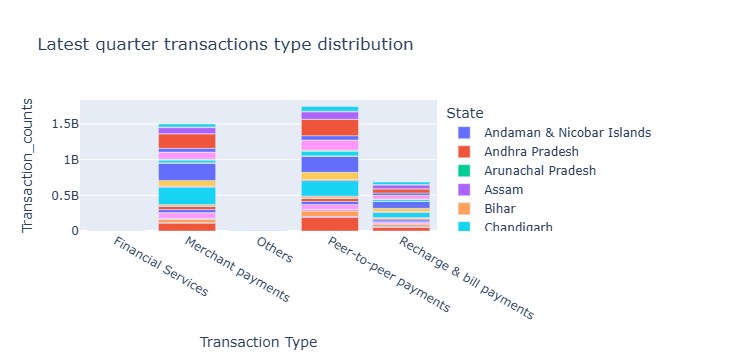

In [15]:
#Q7 Transaction Distribution 

Latest_year = State_tnx[State_tnx['Year']==State_tnx['Year'].max()]
Latest_quarter = Latest_year[Latest_year['Quarter']==Latest_year['Quarter'].max()]

Transaction_segregation = Latest_quarter.groupby(['State','Transaction Type']).agg(Transaction_counts=('Transactions','sum')).reset_index()

px.bar(Transaction_segregation,
       x='Transaction Type',
       y='Transaction_counts',
       color='State',
      title='Latest quarter transactions type distribution' )


In [17]:
# Q8 Identifying unique district and district code 

Unique_district = District[['District','Code']]
Unique_district = Unique_district.drop_duplicates()
Unique_district.to_csv('Unique_district.csv',mode='w',index=False,header=True)


In [19]:
# Q9  Data Quality Checks 
Total_transactions_district_level = (District.groupby(['State','District'])['Transactions'].sum().reset_index()).groupby('State')['Transactions'].sum()
Total_amount_district_level = (District.groupby(['State','District'])['Amount (INR)'].sum().reset_index()).groupby('State')['Amount (INR)'].sum()
Total_users_district_level = (District.groupby(['State','District'])['Registered Users'].sum().reset_index()).groupby('State')['Registered Users'].sum()

Total_transactions_state_level = State_tnx_users.groupby('State')['Transactions'].sum()
Total_amount_state_level = State_tnx_users.groupby('State')['Amount (INR)'].sum()
Total_Users_state_level = State_tnx_users.groupby('State')['Registered Users'].sum()


In [21]:
Total_transactions_district_level == Total_transactions_state_level
Total_users_district_level == Total_Users_state_level

#Total_amount_district_level[Total_amount_district_level == Total_amount_state_level]
#Total_amount_district_level[Total_amount_district_level != Total_amount_state_level]
Meger_amount_state_district = pd.merge(Total_amount_district_level,Total_amount_state_level,on='State',how='left')
Meger_amount_state_district.columns
Meger_amount_state_district['Amount Value Same'] = np.where(Meger_amount_state_district['Amount (INR)_x']==Meger_amount_state_district['Amount (INR)_y'],True,False)
Meger_amount_state_district


,Amount (INR)_x,Amount (INR)_y,Amount Value Same
State,,,
Andaman & Nicobar Islands,3.641818e+09,3.641818e+09,True
Andhra Pradesh,3.860292e+12,3.187847e+12,False
Arunachal Pradesh,2.225183e+10,2.225183e+10,False
Assam,2.814087e+11,2.814087e+11,False
Bihar,1.639579e+12,1.639579e+12,False
Chandigarh,5.371208e+10,5.371208e+10,False
Chhattisgarh,4.156353e+11,4.156353e+11,False
Dadra & Nagar Haveli and Daman & Diu,1.865878e+10,1.865878e+10,False
Delhi,1.649942e+12,1.649942e+12,False


In [23]:
District_demographics['Population'] = (District_demographics.groupby('State')['Population']
                                       .transform(lambda x : x.mask(x==0,x[x>0].mean())).
                                       round())
Population = District_demographics.groupby('State').agg(Total_population=('Population','sum'))
Users = State_tnx_users.groupby('State')['Registered Users'].sum()
Merger = pd.merge(Population,Users,on='State',how='inner').reset_index()
Merger['User_to_Population_Ratio'] = (
    Merger['Registered Users'] / Merger['Total_population']
).round(2)
Merger

,State,Total_population,Registered Users,User_to_Population_Ratio
0,Andaman & Nicobar Islands,380581.0,408396,1.07
1,Andhra Pradesh,49378776.0,158007957,3.20
2,Arunachal Pradesh,1911959.0,1862214,0.97
3,Assam,34461385.0,26860751,0.78
4,Bihar,103817951.0,115284760,1.11
5,Chandigarh,1055450.0,3801466,3.60
6,Chhattisgarh,25867958.0,37448388,1.45
7,Dadra & Nagar Haveli and Daman & Diu,586956.0,2701112,4.60
8,Delhi,20518595.0,95374654,4.65
9,Goa,1457723.0,4755320,3.26


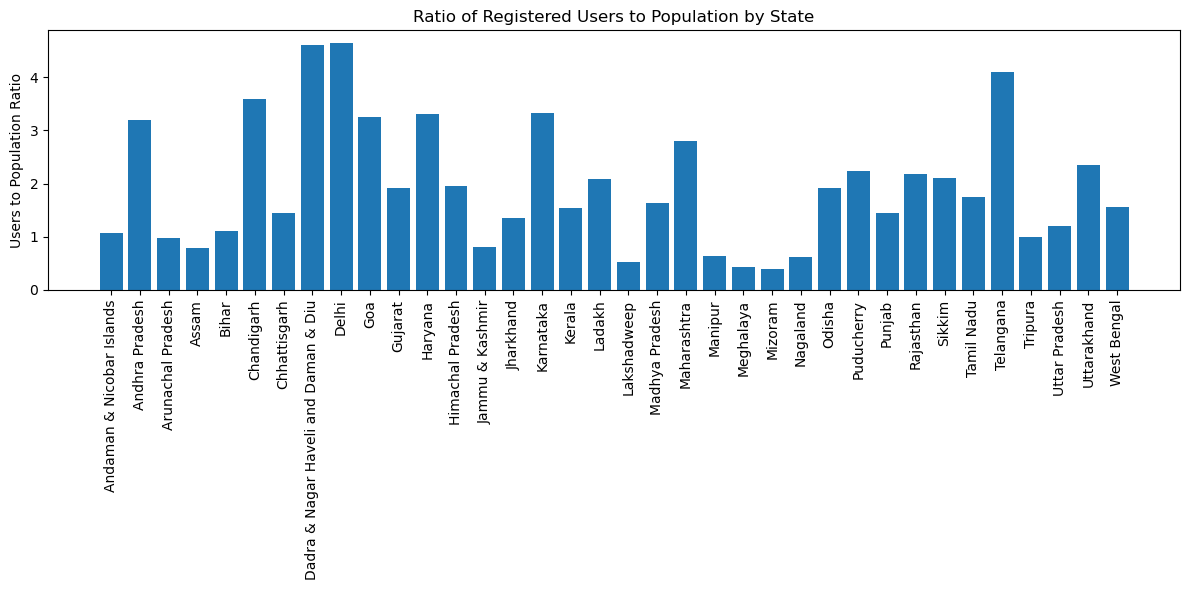

In [25]:
plt.figure(figsize=(12,6))
plt.bar(
    Merger['State'],
    Merger['User_to_Population_Ratio']
)

plt.xticks(rotation=90)
plt.ylabel('Users to Population Ratio')
plt.title('Ratio of Registered Users to Population by State')
plt.tight_layout()
plt.show()

In [27]:
# Q10  Correlation between district transactions and density over the years 
import plotly.express as px
tnx_volume_density = (District[['District','Transactions']].
                      merge(District_demographics[['District','Density']],
                            on='District',how='inner'))

tnx_volume_density = (tnx_volume_density.groupby('District').
                      agg(Transactions = ('Transactions','sum'),
                          Density = ('Density','mean')).reset_index())

correlation = tnx_volume_density['Density'].corr(tnx_volume_density['Transactions'])

print(f"Correlation between density and transaction volume: {round(correlation,2)}")


Correlation between density and transaction volume: 0.42


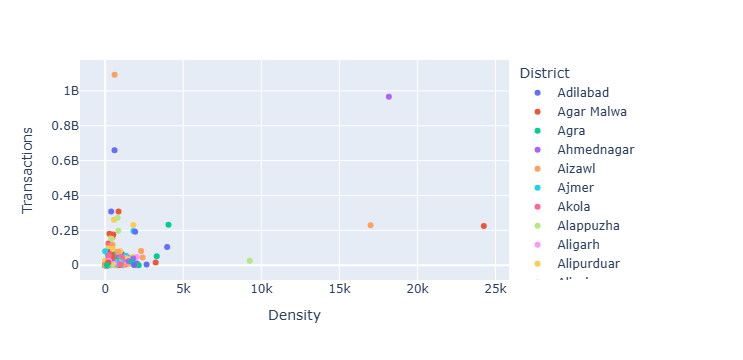

In [29]:
# Q10 part 2 plotting scatter plot chart 
px.scatter(tnx_volume_density,
           x='Density',
           y='Transactions',
          color='District')

In [30]:
# Q11 Calculate average transaction per user by state 
average_tnx_per_user = (State_tnx_users.groupby('State')
 .agg(total_amount = ('Amount (INR)','sum'),
      total_users = ('Registered Users','sum')).reset_index())

average_tnx_per_user['Average Tnx'] = (average_tnx_per_user['total_amount']
                                       /average_tnx_per_user['total_users'])

print(f'Top 5 State highest avg amount \n{average_tnx_per_user[['State','Average Tnx']][['State','Average Tnx']].sort_values(by='Average Tnx',ascending=False).head(5)}')
print(f'Top 5 State lowest avg amount \n{average_tnx_per_user[['State','Average Tnx']].sort_values(by='Average Tnx',ascending=True).head(5)}')

Top 5 State highest avg amount 
             State   Average Tnx
31       Telangana  30653.509622
15       Karnataka  21474.282206
1   Andhra Pradesh  20175.233763
28       Rajasthan  17530.768707
8            Delhi  17299.587909
Top 5 State lowest avg amount 
                                   State  Average Tnx
18                           Lakshadweep  5614.898889
32                               Tripura  5727.184275
7   Dadra & Nagar Haveli and Daman & Diu  6907.815954
16                                Kerala  7274.846690
12                      Himachal Pradesh  7317.601442


In [31]:
# Q12 Ratio of each brand user State wise 

State_brand_users = State_device.groupby(['State','Brand']).agg(Brand_users = ('Registered Users','sum')).reset_index()
State_users = State_tnx_users.groupby('State')['Registered Users'].sum()


In [32]:
Brand_ratio_in_states = State_brand_users.merge(State_users,on='State',how='left')
Brand_ratio_in_states['Ratio'] = Brand_ratio_in_states['Brand_users']/Brand_ratio_in_states['Registered Users']*100
Brand_ratio_in_states.loc[:,['State','Brand','Ratio']]

,State,Brand,Ratio
0,Andaman & Nicobar Islands,Apple,2.285527
1,Andaman & Nicobar Islands,Huawei,2.815160
2,Andaman & Nicobar Islands,Lenovo,1.312941
3,Andaman & Nicobar Islands,Motorola,2.323970
4,Andaman & Nicobar Islands,OnePlus,3.770115
...,...,...,...
443,West Bengal,Others,12.150767
444,West Bengal,Realme,6.462768
445,West Bengal,Samsung,21.156304
446,West Bengal,Vivo,13.002522


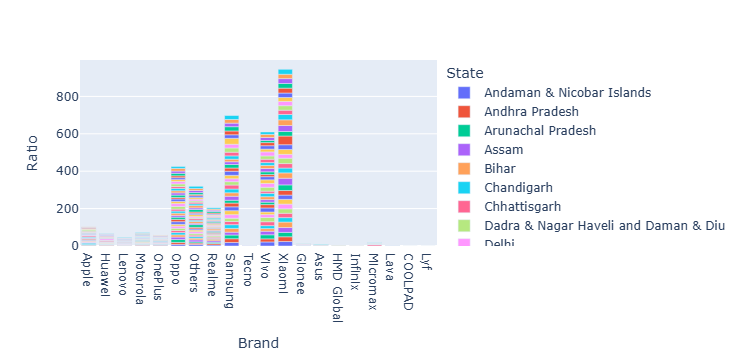

In [33]:
# Q12 part 2 creating bar chart for the data above 
px.bar(Brand_ratio_in_states,
       x='Brand',
       y='Ratio',
      color='State')

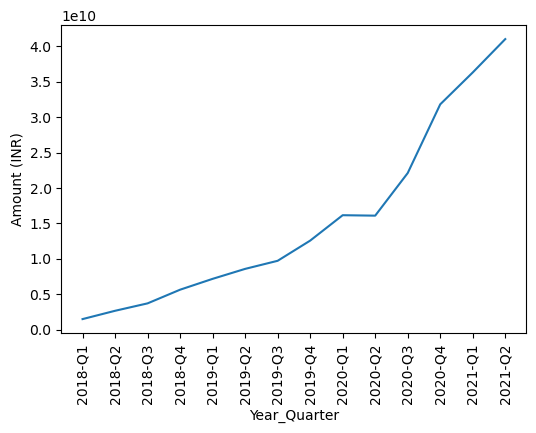

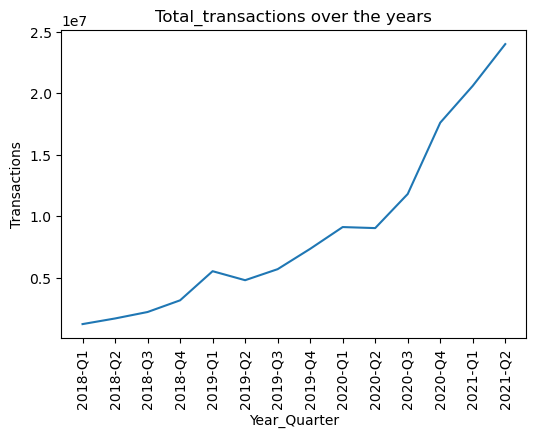

In [291]:
# Q13 Data visualization for the total transactions and total amount over the years and quarters
import matplotlib.pyplot as plt
amount_by_years = (State_tnx_users[State_tnx_users['State']=='Uttarakhand']
                   .groupby(['Year','Quarter'])['Amount (INR)'].sum().reset_index())

transactions_by_year = (State_tnx_users[State_tnx_users['State']=='Uttarakhand'].
                        groupby(['Year','Quarter'])['Transactions'].sum().reset_index())

merged_data = amount_by_years.merge(transactions_by_year,on=['Year','Quarter'],how='inner')
merged_data['Year_Quarter']  = merged_data['Year'].astype('str')+'-Q'+merged_data['Quarter'].astype('str')

plt.figure(figsize=(6,4))
sns.lineplot(data=merged_data,x='Year_Quarter',y='Amount (INR)')
plt.xticks(rotation=90)
plt.show()
plt.figure(figsize=(6,4))
sns.lineplot(data=merged_data,x='Year_Quarter',y='Transactions')
plt.title('Total_transactions over the years')
plt.xticks(rotation=90)
plt.show()

In [195]:
# Q14 Creating pie chart for the distribution of transaction types for a above state and quarter 

State_data = State_tnx[(State_tnx['State']=='Uttarakhand')]
State_data = State_data[State_data['Year']==2018]
State_data = State_data[State_data['Quarter']==1]
Total_transactions = State_data.groupby(['Quarter'])['Transactions'].sum().reset_index()
Total_transactions_types=State_data.groupby(['Quarter','Transaction Type'])['Transactions'].sum().reset_index()

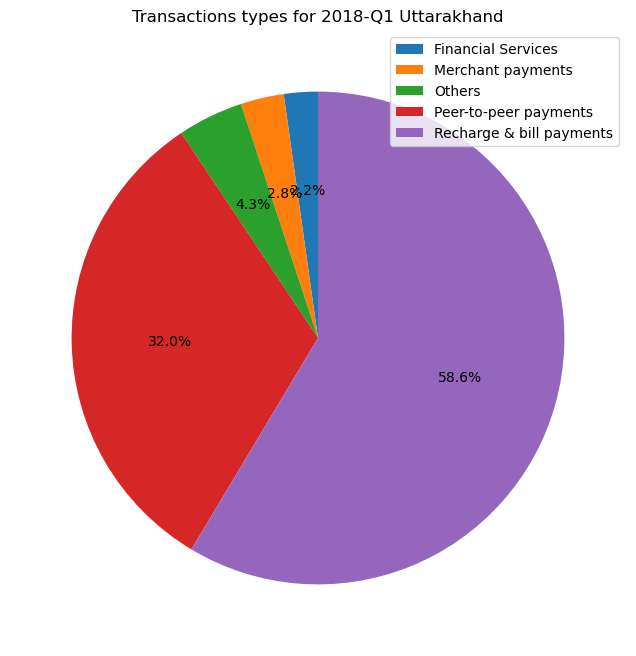

In [324]:
merged_data_set = Total_transactions_types.merge(Total_transactions,on='Quarter',how='inner')
merged_data_set['Ratio'] = merged_data_set['Transactions_x']/merged_data_set['Transactions_y']*100
sizes = merged_data_set['Ratio']

plt.figure(figsize=(8,8))
plt.title('Transactions types for 2018-Q1 Uttarakhand')
plt.pie(sizes,autopct='%1.1f%%',startangle=90)
plt.legend(merged_data_set['Transaction Type'])
plt.show()

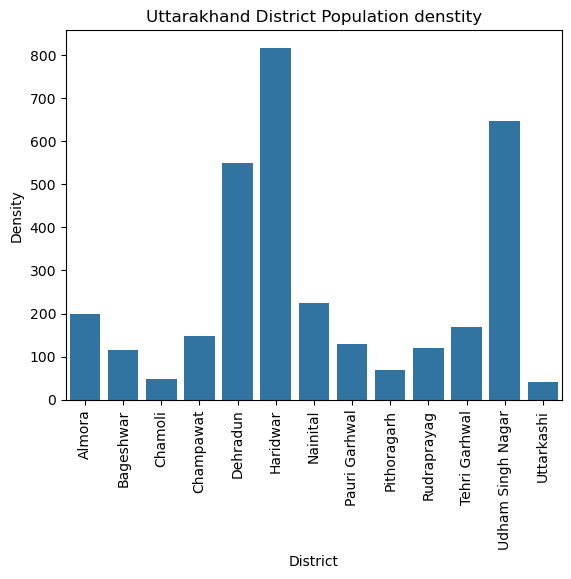

In [368]:
# Q15 Selective state population density bar plot 
State_selection = District_demographics[District_demographics['State']=='Uttarakhand']
sns.barplot(State_selection,x='District',y='Density')
plt.title('Uttarakhand District Population denstity')
plt.xticks(rotation=90)
plt.show()